In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 211s 1us/step


In [4]:
encoder = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(2)  # 2D latent space
])

decoder = models.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(8 * 8 * 64, activation='relu'),
    layers.Reshape((8, 8, 64)),
    layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
    layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
    layers.Conv2D(3, 3, padding='same', activation='sigmoid')
])

input_img = tf.keras.Input(shape=(32, 32, 3))
encoded = encoder(input_img)
decoded = decoder(encoded)

autoencoder = tf.keras.Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_2 (Sequential)            │ (None, 2)                   │          27,586 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_3 (Sequential)            │ (None, 32, 32, 3)           │          68,547 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 96,133 (375.52 KB)

 Trainable params: 96,133 (375.52 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train autoencoder
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, validation_data=(x_test, x_test))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0460 - val_loss: 0.0373
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0372 - val_loss: 0.0371
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0370 - val_loss: 0.0369
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0368 - val_loss: 0.0369
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0369 - val_loss: 0.0368
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0368 - val_loss: 0.0367
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0365 - val_loss: 0.0368
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0367 - val_loss: 0.0367
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0366 - val_loss: 0.0368
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0367 - val_loss: 0.0367


In [6]:
# Extract 2D features
encoded_features = encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


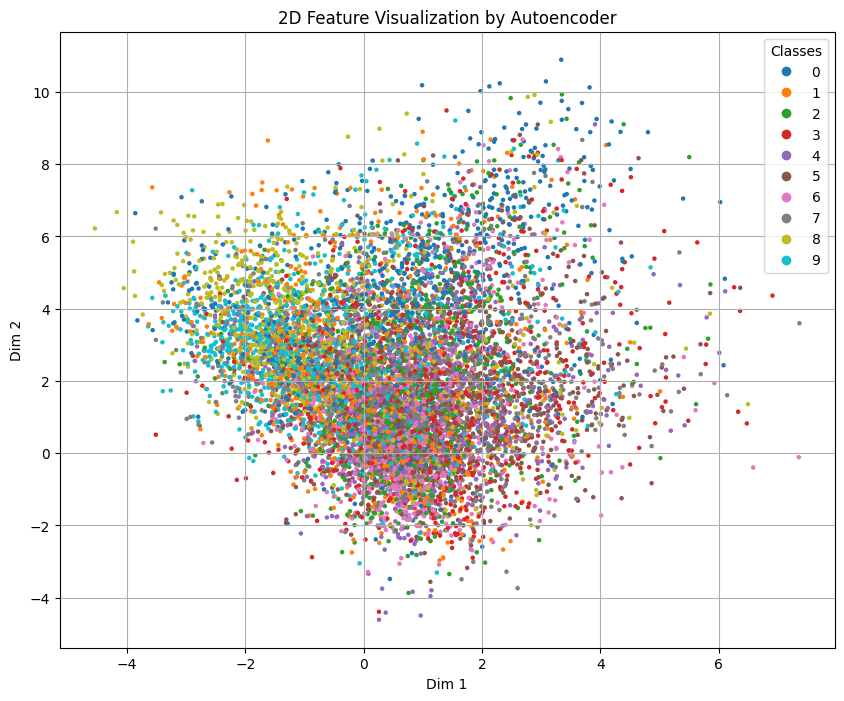

In [7]:
# Visualize 2D features
plt.figure(figsize=(10, 8))
scatter = plt.scatter(encoded_features[:, 0], encoded_features[:, 1], c=y_test, cmap='tab10', s=5)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("2D Feature Visualization by Autoencoder")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()

In [8]:

# ========== Pre-trained CNN (MobileNetV2) Feature Comparison ==========

base_model = tf.keras.applications.MobileNetV2(input_shape=(96, 96, 3),
                                               include_top=False,
                                               pooling='avg',
                                               weights='imagenet')

In [9]:

# Resize CIFAR-10 to MobileNetV2 input
x_test_resized = tf.image.resize(x_test, (96, 96))
cnn_features = base_model.predict(x_test_resized, batch_size=128)

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step


In [11]:
# PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(cnn_features)
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_features = tsne.fit_transform(cnn_features)

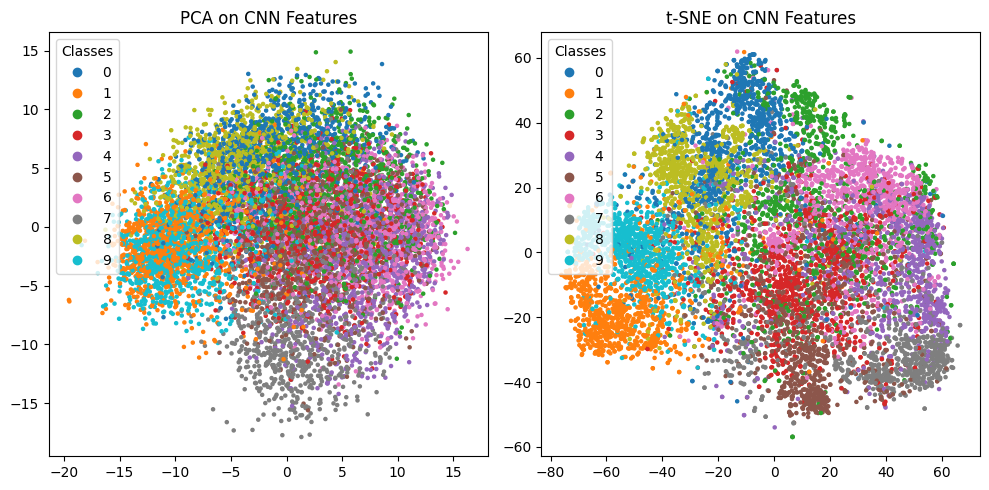

In [13]:
# Plot PCA features
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=y_test, cmap='tab10', s=5)
plt.title("PCA on CNN Features")
plt.legend(*scatter.legend_elements(), title="Classes")

# Plot t-SNE features
plt.subplot(1, 2, 2)
scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=y_test, cmap='tab10', s=5)
plt.title("t-SNE on CNN Features")
plt.legend(*scatter.legend_elements(), title="Classes")

plt.tight_layout()
plt.show()